In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [4]:
costco = pd.read_csv('../../data/demand_costco.csv')
costco.head()


,x,t
0,1,1
1,0,2
2,0,3
3,1,4
4,1,5


In [5]:
freq_tab = costco["x"].value_counts(normalize=True).reset_index()

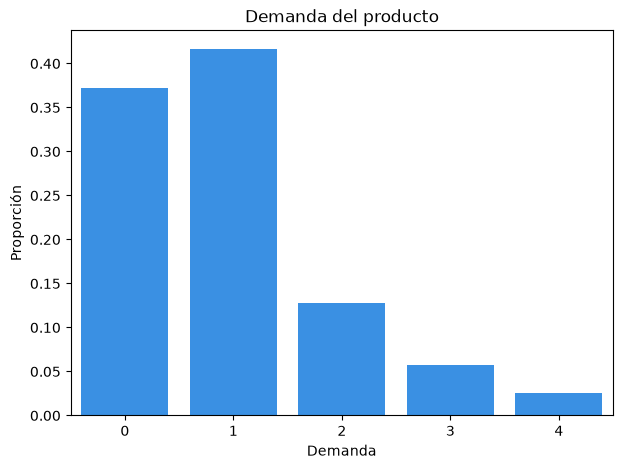

In [6]:
plt.figure(figsize = (7, 5))
sns.barplot(data = freq_tab, x = "x", y = "proportion", color = "dodgerblue")
plt.xlabel("Demanda")
plt.ylabel("Proporción")
plt.title("Demanda del producto")
plt.show();


In [7]:
lambda_hat = costco["x"].mean()

In [8]:
freq_tab = freq_tab.sort_values(by = "x")
probs = stats.poisson.pmf(freq_tab["x"].to_numpy(), lambda_hat)

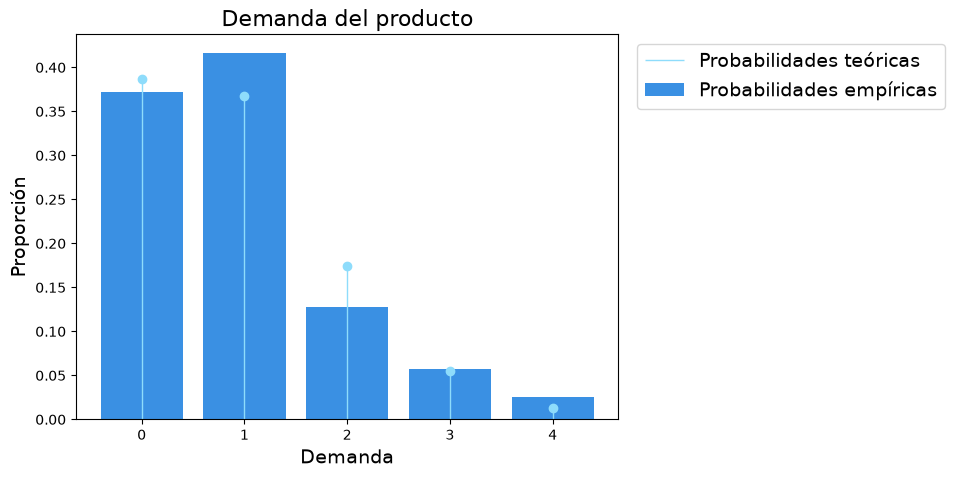

In [9]:
plt.figure(figsize = (7, 5))
sns.barplot(data = freq_tab, x = "x", y = "proportion",
            color = "dodgerblue", label = "Probabilidades empíricas")
plt.xlabel("Demanda", fontsize = 14)
plt.ylabel("Proporción", fontsize = 14)
plt.title("Demanda del producto", fontsize = 16)

for i, value in enumerate(probs[:-1]):
    plt.vlines(i, 0, value, color = "#8EDCFB", lw = 1)
    plt.plot(i, value, marker = "o", color = "#8EDCFB")

plt.vlines(4, 0, probs[4], color = "#8EDCFB", lw = 1,
           label = "Probabilidades teóricas")
plt.plot(4, probs[4], marker = "o", color = "#8EDCFB")
plt.legend(bbox_to_anchor = (1.62, 1), loc = "upper right", fontsize = 14)
plt.show();

In [10]:
KS_test = stats.kstest(costco["x"], stats.poisson(lambda_hat,).cdf)

In [11]:
D_obs = KS_test.statistic

In [12]:
poisson_sim = stats.poisson(lambda_hat)

In [13]:
n = len(costco["x"])
D_sim = []

In [14]:
for i in range(10000):
    ## Simulamos datos de la distribución hipotética
    x_sim = poisson_sim.rvs(size = n)

    ## Estimamos el parámetro de los datos simulados bajo la hipótesis nula
    lambda_hat_sim = x_sim.mean()

    ## Realizamos una prueba de Kolmogorov-Smirnov
    ## y retenemos la estadística observada
    D0 = stats.kstest(x_sim, stats.poisson(lambda_hat_sim).cdf).statistic

    ## Guardamos el valor de la estadística en la lista
    D_sim.append(D0)

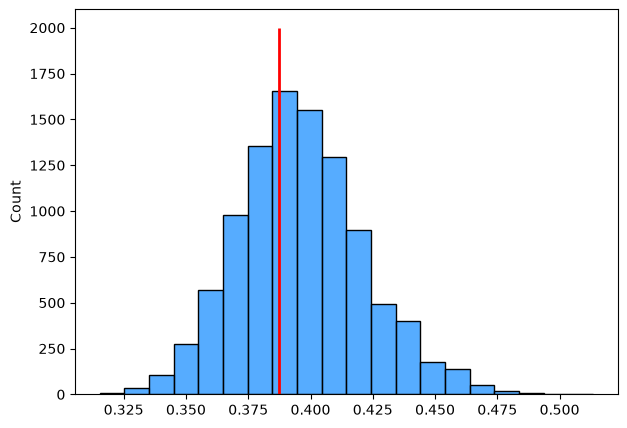

In [15]:
plt.figure(figsize = (7, 5))
sns.histplot(D_sim, bins = 20, color = "dodgerblue")
plt.vlines(D_obs, 0, 2000, color = "red", linewidth = 2)
plt.show();

In [16]:
((D_sim >= D_obs).sum() + 1)/(len(D_sim) + 1)

np.float64(0.6276372362763724)

In [19]:
p_0 = stats.poisson.pmf([3, 2, 1, 0], lambda_hat)
p_0[0] = 1 - p_0[1:].sum()
p_0

array([0.07111454, 0.17426945, 0.36737885, 0.38723716])

In [20]:
import numpy as np

P = np.array([[0.0711, 0.1743, 0.3674, 0.3872],
              [0.6128, 0.3872, 0.0000, 0.0000],
              [0.2454, 0.3674, 0.3872, 0.0000],
              [0.0711, 0.1743, 0.3674, 0.3872]])

In [21]:
from numpy.linalg import eig, inv

Lambda, Q = eig(P)

In [22]:
Q_1 = inv(Q)

In [23]:
Lambda = np.diag(Lambda)

In [26]:
PP = Q @ Lambda @ Q_1
np.round(PP, 4)
P

array([[0.0711, 0.1743, 0.3674, 0.3872],
       [0.6128, 0.3872, 0.    , 0.    ],
       [0.2454, 0.3674, 0.3872, 0.    ],
       [0.0711, 0.1743, 0.3674, 0.3872]])

In [31]:
Lambda_48 = Lambda ** 48
np.round(Lambda_48, 4)
Lambda_48

array([[ 1.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        -6.11803166e-28-8.60920913e-28j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, -6.11803166e-28+8.60920913e-28j]])

In [30]:
P_48 = Q @ Lambda_48 @ Q_1
np.round(P_48, 4)
P_48

array([[0.27315352+1.11022302e-16j, 0.28700911+2.77555756e-17j,
        0.26724429-1.87189704e-44j, 0.17259308+5.55111512e-17j],
       [0.27315352+1.11022302e-16j, 0.28700911+2.77555756e-17j,
        0.26724429+1.21979011e-44j, 0.17259308+5.55111512e-17j],
       [0.27315352+1.11022302e-16j, 0.28700911+2.77555756e-17j,
        0.26724429-3.82558846e-45j, 0.17259308+5.55111512e-17j],
       [0.27315352+1.11022302e-16j, 0.28700911+2.77555756e-17j,
        0.26724429+2.19523866e-44j, 0.17259308+5.55111512e-17j]])